In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from typing import Optional
import matplotlib
from matplotlib.cm import PRGn, YlGnBu
from plottable import ColumnDefinition, Table
from plottable.cmap import normed_cmap
from plottable.plots import bar

In [ ]:
import os

In [ ]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

# Define functions

In [3]:
class MetricPlotter:
    """Class to plot benchmarking metrics from pre-computed data.

    Parameters
    ----------
    results_df
        DataFrame containing the metrics results. Columns are methods, rows are metrics.
    """

    def __init__(self, results_df: pd.DataFrame):
        self.results_df = results_df.copy()

    def get_scaled_results(self, min_max_scale: bool = True, recompute_total :bool = False) -> pd.DataFrame:
        df = self.results_df #.transpose()

        if min_max_scale:
            scaler = MinMaxScaler()
            df = pd.DataFrame(
                scaler.fit_transform(df),
                columns=df.columns,
                index=df.index,
            )
            
        if recompute_total:
            df["Total"] = df.mean(axis=1)
        return df

    def plot_results(self, min_max_scale: bool = True, 
                     show: bool = True, save_path: Optional[str] = None,
                     show_n: Optional[int] = None,
                     recompute_total: Optional[bool]=False
                    ):
        df = self.get_scaled_results(min_max_scale=min_max_scale, recompute_total=recompute_total)
        plot_df = df.sort_values(by="Total", ascending=False).astype(float)
        plot_df["Method"] = plot_df.index
        
        if show_n:
            plot_df1 = plot_df.head(n=show_n)
            plot_df2 = plot_df.tail(n=show_n)
            plot_df = pd.concat([plot_df1, plot_df2])
        
        cmap_fn = lambda col_data: normed_cmap(col_data, cmap=PRGn, num_stds=2.5)

        column_definitions = [
            ColumnDefinition("Method", width=1.5, textprops={"ha": "left", "weight": "bold"}),
        ] + [
            ColumnDefinition(
                col,
                title=col.replace(" ", "\n", 1),
                width=1,
                textprops={"ha": "center", "bbox": {"boxstyle": "circle", "pad": 0.25}},
                cmap=cmap_fn(plot_df[col]),
                formatter="{:.2f}",
            )
            for col in plot_df.columns if col not in ["Method", "Total"]
        ] + [
            ColumnDefinition(
                "Total",
                width=1,
                title="Total",
                plot_fn=bar,
                plot_kw={
                    "cmap": YlGnBu,
                    "plot_bg_bar": False,
                    "annotate": True,
                    "height": 0.9,
                    "formatter": "{:.2f}",
                },
                border="left",
            )
        ]

        with matplotlib.rc_context({"svg.fonttype": "none"}):
            fig, ax = plt.subplots(figsize=(len(plot_df.columns) * 1.25, 3 + 0.3 * len(plot_df)))
            tab = Table(
                plot_df,
                cell_kw={"linewidth": 0, "edgecolor": "k"},
                column_definitions=column_definitions,
                ax=ax,
                row_dividers=True,
                footer_divider=True,
                textprops={"fontsize": 10, "ha": "center"},
                row_divider_kw={"linewidth": 1, "linestyle": (0, (1, 5))},
                col_label_divider_kw={"linewidth": 1, "linestyle": "-"},
                column_border_kw={"linewidth": 1, "linestyle": "-"},
                index_col="Method",
            ).autoset_fontcolors(colnames=plot_df.columns)

        if save_path:
            fig.savefig(save_path, facecolor=ax.get_facecolor(), dpi=300)

        if show:
            plt.show()

        plt.close(fig)


# By target_pathway

In [4]:
df = pd.read_csv('scib_results_target_pathway.csv')

In [ ]:
df = df.set_index('Embedding')

In [6]:
metrics = df[df.index == 'Metric Type'].T
metrics

Embedding,Metric Type
Isolated labels,Bio conservation
KMeans NMI,Bio conservation
KMeans ARI,Bio conservation
Silhouette label,Bio conservation
cLISI,Bio conservation
BRAS,Batch correction
iLISI,Batch correction
KBET,Batch correction
Graph connectivity,Batch correction
PCR comparison,Batch correction


In [7]:
df = df[df.index != 'Metric Type']
# df = df[~df.index.str.contains('X_')]

In [8]:
# drop metrics that compare with uncorrected space


In [ ]:
df = df.astype(float)

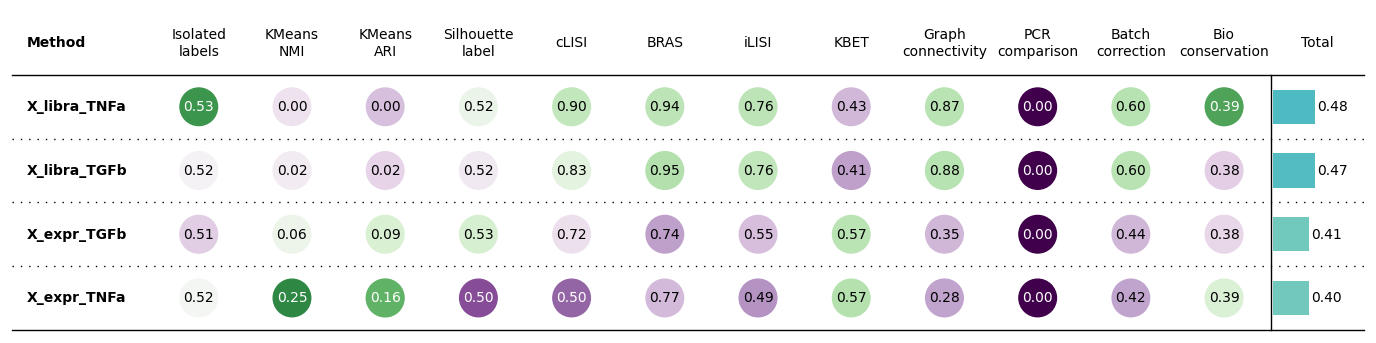

In [10]:
plotter = MetricPlotter(results_df=df)
plotter.plot_results(min_max_scale=False, show=True)


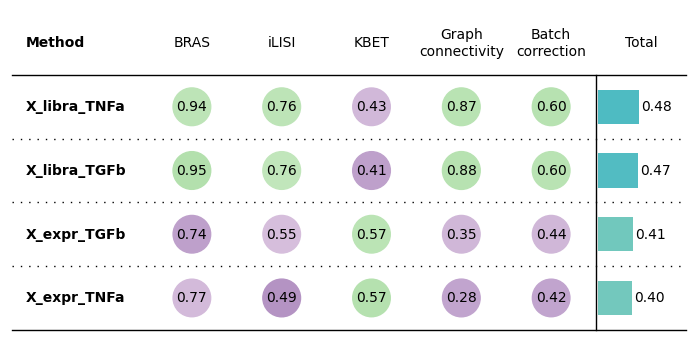

In [12]:
# only keep Batch correction methods
plotter = MetricPlotter(results_df=df[['BRAS', 'iLISI', 'KBET', 'Graph connectivity', 'Batch correction', 'Total']])
plotter.plot_results(min_max_scale=False, show=True, save_path = 'scib_target_pathway.pdf')


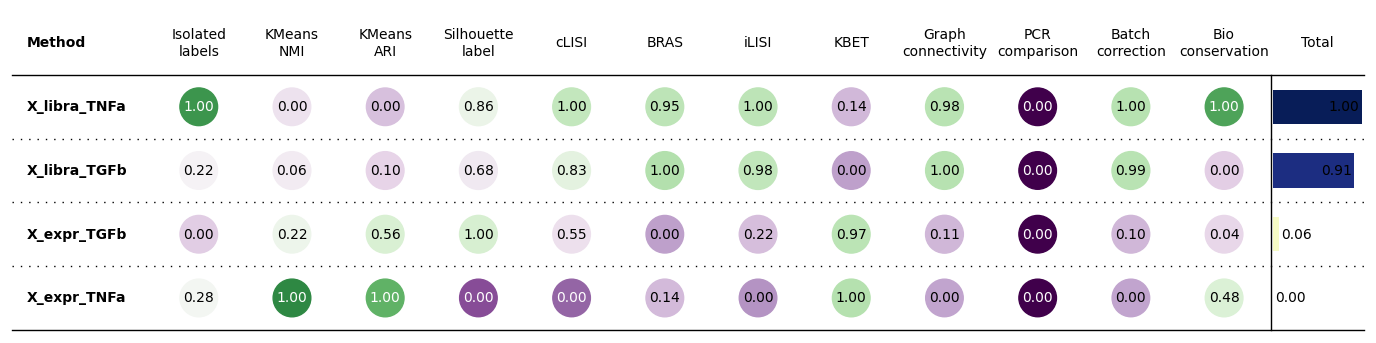

In [ ]:
plotter = MetricPlotter(results_df=df)
plotter.plot_results(min_max_scale=True, show=True)


In [ ]:
# plotter = MetricPlotter(results_df=df[['Isolated labels', 'KMeans NMI', 'KMeans ARI', 'Silhouette label', 'cLISI']])
# plotter.plot_results(min_max_scale=False, show=True, show_n = 3, recompute_total = True)
